Particles simulated: 10,000
Particles scattered < 10°: 9,774
Particles scattered > 90°: 15


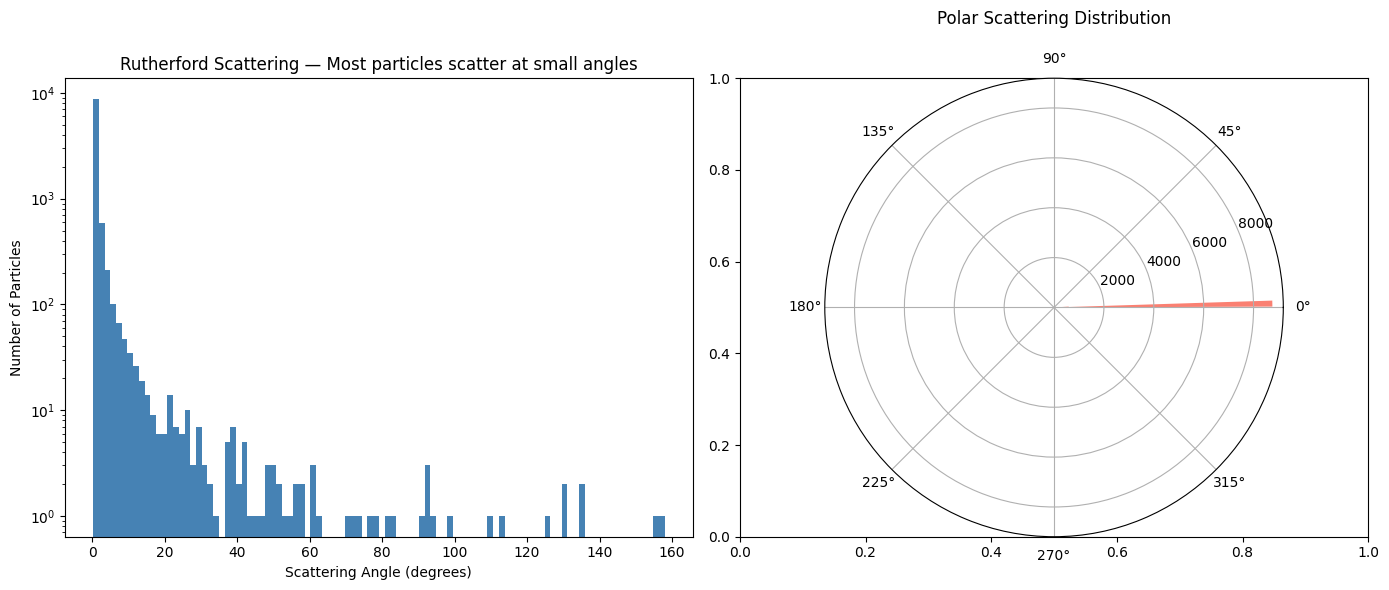

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit')

n_particles = 10_000
a = 1.0  # normalized Coulomb parameter

# Much larger b_max so most particles miss the nucleus
b_max = 500.0
b = np.random.uniform(0.1, b_max, n_particles)

# Rutherford formula
theta = 2 * np.arctan(a / b)

print(f'Particles simulated: {n_particles:,}')
print(f'Particles scattered < 10°: {np.sum(np.degrees(theta) < 10):,}')
print(f'Particles scattered > 90°: {np.sum(theta > np.pi/2):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(np.degrees(theta), bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Scattering Angle (degrees)')
axes[0].set_ylabel('Number of Particles')
axes[0].set_title('Rutherford Scattering — Most particles scatter at small angles')
axes[0].set_yscale('log')

ax_polar = fig.add_subplot(122, projection='polar')
ax_polar.hist(theta, bins=100, color='salmon', edgecolor='none')
ax_polar.set_title('Polar Scattering Distribution', pad=20)

plt.tight_layout()
plt.savefig('results/02_particle_scattering.png', bbox_inches='tight')
plt.show()

True Z:      47 (Silver)
Estimated Z: 47
Error: 0 units


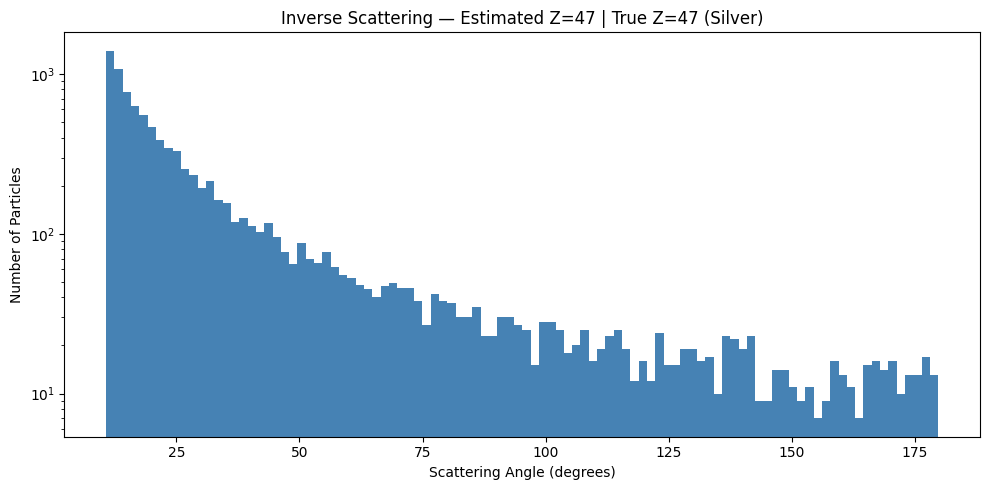

In [2]:
# === INVERSE PROBLEM ===
# A mystery material produces scattering data.
# Can we determine its atomic number Z from the angles alone?

# Step 1 — Simulate mystery material (Z unknown to the model)
Z_true = 47  # Silver — we pretend we dont know this
a_true = float(Z_true)
b_mystery = np.random.uniform(0.1, 500.0, n_particles)
theta_mystery = 2 * np.arctan(a_true / b_mystery)

# Step 2 — Back calculate a (and therefore Z) from scattering data
# From Rutherford formula: a = b * tan(theta/2)
a_estimated = np.median(b_mystery * np.tan(theta_mystery / 2))
Z_estimated = round(a_estimated)

print(f'True Z:      {Z_true} (Silver)')
print(f'Estimated Z: {Z_estimated}')
print(f'Error: {abs(Z_true - Z_estimated)} units')

# Step 3 — Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.degrees(theta_mystery), bins=100, 
        color='steelblue', edgecolor='none')
ax.set_xlabel('Scattering Angle (degrees)')
ax.set_ylabel('Number of Particles')
ax.set_title(f'Inverse Scattering — Estimated Z={Z_estimated} | True Z={Z_true} (Silver)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('results/02_inverse_scattering.png', bbox_inches='tight')
plt.show()